Fold 1 - Accuracy: 0.885
Fold 1, Class bitter - AUC: 0.957
Fold 1, Class sour - AUC: 0.987
Fold 1, Class sweet - AUC: 0.974
Fold 2 - Accuracy: 0.870
Fold 2, Class bitter - AUC: 0.938
Fold 2, Class sour - AUC: 0.982
Fold 2, Class sweet - AUC: 0.974
Fold 3 - Accuracy: 0.859
Fold 3, Class bitter - AUC: 0.927
Fold 3, Class sour - AUC: 0.975
Fold 3, Class sweet - AUC: 0.969
Fold 4 - Accuracy: 0.878
Fold 4, Class bitter - AUC: 0.955
Fold 4, Class sour - AUC: 0.988
Fold 4, Class sweet - AUC: 0.972
Fold 5 - Accuracy: 0.885
Fold 5, Class bitter - AUC: 0.944
Fold 5, Class sour - AUC: 0.976
Fold 5, Class sweet - AUC: 0.967


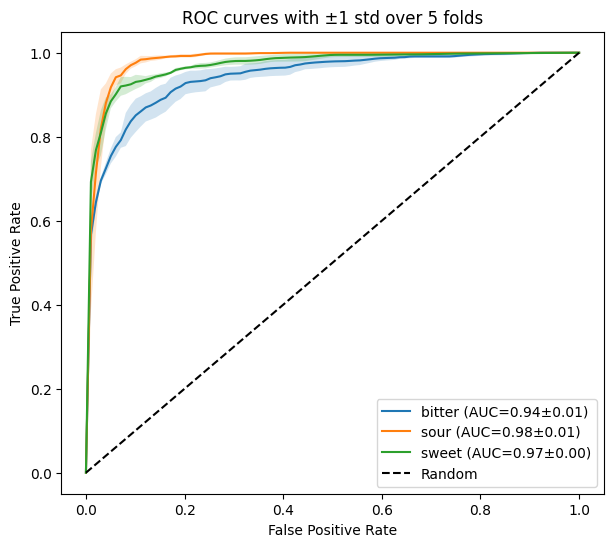

✅ Wykres zapisany w: figures/roc_curves.png

Average metrics per class:
bitter: precision=0.84, recall=0.81, f1=0.83
sour: precision=0.87, recall=0.95, f1=0.91
sweet: precision=0.92, recall=0.86, f1=0.89


<Figure size 640x480 with 0 Axes>

In [1]:
# run_cv_plot.py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fingerprints import smiles_to_fingerprint
from roc_utils import plot_roc_cv

# -----------------------------
# Wczytanie danych
# -----------------------------
df_balanced = pd.read_csv("df_to_RF.csv")

# -----------------------------
# Przygotowanie macierzy fingerprintów
# -----------------------------
X_train_smiles = df_balanced["Canonicalized SMILES"].tolist()
X_train = np.vstack([smiles_to_fingerprint(s) for s in X_train_smiles])
y_train = df_balanced['Canonicalized Taste'].values
classes = np.unique(y_train)

# -----------------------------
# Wykres ROC-AUC po 5-fold CV
# -----------------------------
avg_metrics = plot_roc_cv(X_train, y_train, classes, n_splits=5)

# -----------------------------
# Zapis wykresu do folderu 'figures'
# -----------------------------
fig_folder = "figures"
os.makedirs(fig_folder, exist_ok=True)

plt.savefig(os.path.join(fig_folder, "roc_curves.png"), dpi=300)
print(f"✅ Wykres zapisany w: {fig_folder}/roc_curves.png")

# -----------------------------
# Wypisanie średnich metryk dla klas
# -----------------------------
print("\nAverage metrics per class:")
for cls, m in avg_metrics.items():
    print(f"{cls}: precision={m['precision']:.2f}, recall={m['recall']:.2f}, f1={m['f1-score']:.2f}")
